In [144]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors
from sklearn.linear_model import RidgeClassifier

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [145]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

In [146]:
data_set = df.copy()
y = data_set['target_class']
X = data_set.drop(columns=["target_class"])

In [147]:
def ridge_classification(train_x, train_y, test_x, test_y, alpha):
    ridgereg  = LogisticRegression(
        penalty='l2',       # Ridge
        C=alpha,            # inverse of regularization strength
        multi_class='ovr',  # One-vs-Rest
        max_iter=5000
    )
    ridgereg.fit(train_x, train_y)

    train_y_pred = ridgereg.predict(train_x)
    test_y_pred = ridgereg.predict(test_x)

    # Accuracy metrics
    accuracy_train = (train_y_pred == train_y).mean()
    accuracy_test = (test_y_pred == test_y).mean()

    # Use only first class coefficients
    coef_flat = ridgereg.coef_[0]
    return [accuracy_train, accuracy_test, *coef_flat]


def lasso_classification(train_x, train_y, test_x, test_y, alpha):
    if alpha == 0:
        model = LogisticRegression(
            penalty=None,
            solver='saga',
            multi_class='ovr',
            max_iter=10000
        )
    else:
        C = 1 / alpha
        model = LogisticRegression(
            penalty='l1',
            C=C,
            solver='saga',
            multi_class='ovr',
            max_iter=10000
        )

    model.fit(train_x, train_y)

    # Predictions
    train_y_pred = model.predict(train_x)
    test_y_pred = model.predict(test_x)

    # Accuracy
    accuracy_train = (train_y_pred == train_y).mean()
    accuracy_test = (test_y_pred == test_y).mean()

    # Take only first class coefficients to match feature count
    coef_flat = model.coef_[0]  # shape = (n_features,)

    return [accuracy_train, accuracy_test, *coef_flat]


In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)

# 1. Ridge Regression


In [149]:
alpha_ridge = np.logspace(-6, 3, 20)

# DataFrame setup
feature_names = X.columns
col = ['accuracy_train', 'accuracy_test'] + list(feature_names)
ind = [f'alpha_{alpha:.2g}' for alpha in alpha_ridge]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col, dtype=float)

# Loop
for i, alpha in enumerate(alpha_ridge):
    results = ridge_classification(
        X_train_scaled, y_train, X_test_scaled, y_test, alpha
    )
    coef_matrix_ridge.iloc[i, :] = results
coef_matrix_ridge

,accuracy_train,accuracy_test,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,...,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_regression
alpha_1e-06,0.439583,0.416667,-0.000049,0.000109,0.000193,-0.000245,-0.000074,-0.000232,0.000172,-0.000110,...,0.000341,-0.000082,0.0,0.000168,0.000016,0.000021,0.0,-0.000015,0.000387,0.000373
alpha_3e-06,0.605833,0.555000,-0.000147,0.000322,0.000571,-0.000721,-0.000221,-0.000684,0.000510,-0.000325,...,0.001007,-0.000241,0.0,0.000494,0.000048,0.000063,0.0,-0.000046,0.001141,0.001101
alpha_8.9e-06,0.629167,0.591667,-0.000445,0.000932,0.001672,-0.002089,-0.000660,-0.001995,0.001497,-0.000935,...,0.002916,-0.000703,0.0,0.001434,0.000145,0.000186,0.0,-0.000137,0.003308,0.003215
alpha_2.6e-05,0.632917,0.600000,-0.001390,0.002571,0.004748,-0.005750,-0.001988,-0.005609,0.004280,-0.002532,...,0.008044,-0.001973,0.0,0.003974,0.000448,0.000540,0.0,-0.000402,0.009141,0.009059
alpha_7.8e-05,0.674167,0.628333,-0.004525,0.006305,0.012569,-0.014014,-0.006010,-0.014521,0.011504,-0.005898,...,0.019723,-0.005087,0.0,0.009877,0.001438,0.001500,0.0,-0.001150,0.022538,0.023455
alpha_0.00023,0.718333,0.695000,-0.014479,0.012500,0.029353,-0.027238,-0.017495,-0.033017,0.027420,-0.010355,...,0.038977,-0.011348,0.0,0.020446,0.004669,0.003800,0.0,-0.003053,0.045307,0.051850
alpha_0.0007,0.735000,0.723333,-0.039671,0.019066,0.058164,-0.039046,-0.044392,-0.065342,0.054199,-0.012404,...,0.058658,-0.021454,0.0,0.035804,0.013758,0.008218,0.0,-0.006783,0.071187,0.090651
alpha_0.0021,0.747500,0.723333,-0.083658,0.022419,0.094689,-0.038500,-0.090251,-0.109370,0.083006,-0.009568,...,0.069525,-0.033183,0.0,0.062096,0.032180,0.014118,0.0,-0.011267,0.090134,0.109499
alpha_0.0062,0.752083,0.731667,-0.137293,0.017390,0.127172,-0.016673,-0.148057,-0.144378,0.099001,-0.001457,...,0.070554,-0.038114,0.0,0.122777,0.055591,0.019259,0.0,-0.013776,0.093261,0.047232
alpha_0.018,0.766250,0.755000,-0.192364,-0.000212,0.149951,0.028212,-0.208606,-0.151178,0.101917,0.012677,...,0.057262,-0.028458,0.0,0.278718,0.074207,0.023169,0.0,-0.013804,0.074469,-0.125900


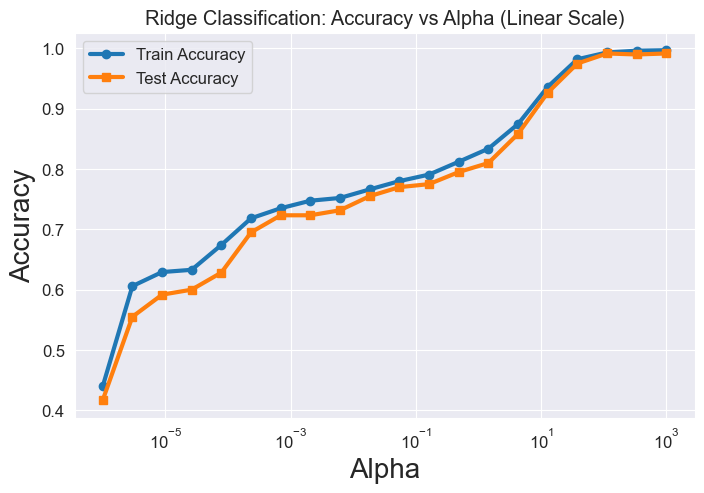

Best alpha: 112.88378916846884
Best test accuracy: 0.9917


In [150]:
plt.figure(figsize=(8,5))
plt.plot(alpha_ridge, coef_matrix_ridge['accuracy_train'], marker='o', label='Train Accuracy')
plt.plot(alpha_ridge, coef_matrix_ridge['accuracy_test'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Ridge Classification: Accuracy vs Alpha (Linear Scale)')
plt.legend()
plt.grid(True)
plt.show()

coef_matrix_ridge['alpha'] = alpha_ridge
best_idx = coef_matrix_ridge['accuracy_test'].astype(float).idxmax()

# Extract values
best_alpha = coef_matrix_ridge.loc[best_idx, 'alpha']
best_accuracy = coef_matrix_ridge.loc[best_idx, 'accuracy_test']

print(f"Best alpha: {best_alpha}")
print(f"Best test accuracy: {best_accuracy:.4f}")

# 2. Lasso


In [151]:
# --- Set alphas ---
alpha_lasso = np.logspace(-6, 1, 10)

# --- Prepare DataFrame ---
feature_names = X.columns
col = ['accuracy_train', 'accuracy_test'] + list(feature_names)
ind = [f'alpha_{a:.2g}' for a in alpha_lasso]
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col, dtype=float)

# --- Fill DataFrame with accuracies + coefficients ---
for i, alpha in enumerate(alpha_lasso):
    result = lasso_classification(
        X_train_scaled, y_train, X_test_scaled, y_test, alpha
    )
    coef_matrix_lasso.iloc[i, 0] = result[0]  # train accuracy
    coef_matrix_lasso.iloc[i, 1] = result[1]  # test accuracy
    coef_matrix_lasso.iloc[i, 2:] = result[2:]  # coefficients for all features

# --- Find best alpha ---
best_idx = coef_matrix_lasso['accuracy_test'].astype(float).idxmax()
best_alpha = alpha_lasso[ind.index(best_idx)]
best_accuracy = coef_matrix_lasso.loc[best_idx, 'accuracy_test']
print(f"Best alpha: {best_alpha:.2e}")
print(f"Best test accuracy: {best_accuracy:.4f}")



Best alpha: 4.64e-02
Best test accuracy: 0.9650


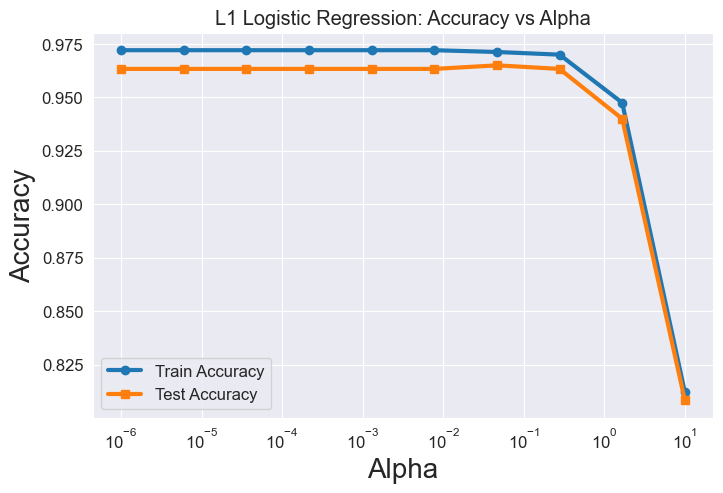

duration_1                       -0.204207
duration_2                       -0.084187
duration_3                        0.062984
duration_4                        0.071959
duration_5                       -0.217456
loudness_level                   -0.044529
popularity_level                  0.061317
tempo_class                       0.043834
time_signature                    0.001773
key_mode                         -0.135229
artist_song_count                 0.089219
album_freq                       -0.592970
movement_index                   -0.093195
intensity_level                  -0.226329
verbal_density                   -0.111204
purity_score                     -0.081090
positivity_index                  0.000665
activity_rate                    40.024028
loudness_intensity                0.757965
happy_dance                      -0.165702
acoustics_instrumental           -0.106376
artists_avg_popularity            0.272901
tempo_vs_genre                  -77.361793
energy_rank

In [152]:
# --- Extract only coefficients ---
coef_only_lasso = coef_matrix_lasso.drop(columns=['accuracy_train', 'accuracy_test'])

# --- Plot accuracy vs alpha ---
plt.figure(figsize=(8,5))
plt.plot(alpha_lasso, coef_matrix_lasso['accuracy_train'], marker='o', label='Train Accuracy')
plt.plot(alpha_lasso, coef_matrix_lasso['accuracy_test'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('L1 Logistic Regression: Accuracy vs Alpha')
plt.grid(True)
plt.legend()
plt.show()

# --- Display coefficients for best alpha ---
best_coef_table = coef_only_lasso.loc[best_idx]
best_coef_table

## 3. Elastic Net Regression
